**To do**
1. ICBHI 데이터 공식 split 필요
    - ~~파일이름 변경~~ → 완료
    - train/test 구분 (공식, 6:4)  
    (Train: 539, Test: 381, Total 920)
    - pretext(80), finetuning(20) 으로 나누기


2. 전처리 고민 (데이터 특성을 고려한 전처리)
    - Sr (4KHz, 16KHz)
    - Augmentation (일단 SpecAug 부터)
    - 호흡 주기 seg
    - 하이퍼 파라미터

3. 일단 Finetuning 성공 문제


In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import os
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import math
from tqdm import tqdm
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


In [3]:
import pandas as pd

csv_path = "../data/ICBHI_challenge_train_test.csv"
df = pd.read_csv(csv_path, delimiter='\t', header=None)

# 컬럼 이름 수정 (좀 더 깔끔하게)
df.columns = ['filename', 'set']

# train, test 데이터 나누기
train_df = df[df['set'] == 'train']
test_df = df[df['set'] == 'test']

## 0. Seed 고정

In [4]:
# import random
# import numpy as np
# import torch

# def seed_everything(seed: int = 42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)  # multi-GPU의 경우
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
    
# # seed 고정
# seed_everything(42)  # 원하는 seed 값을 넣으시면 됩니다

## 1. Data Load

In [5]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import random

# WAV 파일이 있는 디렉토리 경로
data_dir = "../data/ICBHI_final_database"
txt_dir = "../data/ICBHI_final_database"

train_list = sorted(train_df['filename'].tolist())
test_list = sorted(test_df['filename'].tolist())

In [6]:
print(f'Train :{len(train_list)}, Test: {len(test_list)}, Total: {len(train_list) + len(test_list)}')

Train :539, Test: 381, Total: 920


### HyperParameter

**Data Preprocessing**  
1. *Sampling Rate* - (변경 가능)
2. *Waveform*
    - Raw Waveform
    - Wavelet
    - MFCC
    - Mel_spectogram
3. *Augmentation*   - (1st)
    - SpecAug
    - RandomCrop
    - etc..
4. *Size* (5s~8s) - (2nd)
    - repeat
    - padding
5. *Model*          - (3nd)
    - channel (*2, *4)

**Training**  
1. *Pretext*  
    - epoch
    - lr
    - Batch_size
    - EMA momentum
    - weight decay
    - mlp dim
    - warmup  
3. *Finetune*  
    - epoch
    - etc ..

        K: queue size; number of negative keys (default: 65536)
        m: moco momentum of updating key encoder (default: 0.999)
        T: softmax temperature (default: 0.07)

In [42]:
class Args:
    # Data preprocess
    target_sr = 4000 # 4KHz
    frame_size = 1024
    hop_length = 512 # frame_size 절반
    n_mels = 128
    target_sec = 8 
    time_mask_param = 0.5
    freq_mask_param = 0.5
    # Train
    K = 8192
    m = 0.999
    T = 0.07
        
        
    lr = 0.03
    warm = True                      # warm-up 사용 여부
    warm_epochs = 10                # warm-up 적용할 초기 epoch 수
    warmup_from = lr * 0.1             # warm-up 시작 learning rate (보통 lr의 10%)
    warmup_to = lr     

    gpu = 0
    batch_size = 256
    workers = 4
    epochs = 300

    momentum = 0.99
    weight_decay = 1e-4
    data = "./data_path"
    print_freq = 100
    mlp_dim = 128
    mlp = True
    resume = None
    schedule=[120, 160] # schedule
    # target_frames =

args = Args()

#### Dataset util (func)

- get class
- Mel Spectogram 생성 (sr, frame_size, hop_length, n_mels)
- cycle 나누기 (start-end, append list)
- cycle repeat
- spec aug

In [9]:
# cycle 로부터 label 설정
def get_class(cr, wh):
    if cr == 1 and wh == 1:
        return 3
    elif cr == 0 and wh == 1:
        return 2
    elif cr == 1 and wh == 0:
        return 1
    elif cr == 0 and wh == 0:
        return 0
    else:
        return -1

In [10]:
#  Mel Spectrogram 생성 ( sr=16KHz, frame_size=1024, hop_length=512, n_mels=128 )
def generate_mel_spectrogram(waveform, sample_rate, frame_size=args.frame_size, hop_length=args.hop_length, n_mels=args.n_mels):
    if hop_length is None:
        hop_length = frame_size // 2
    mel_spec_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=frame_size,
        hop_length=hop_length,
        n_mels=n_mels
    )
    mel_spectrogram = mel_spec_transform(waveform)
    mel_db = T.AmplitudeToDB()(mel_spectrogram)
    return mel_db

In [11]:
 # 사이클 데이터 Repeat
def repeat_or_truncate_segment(mel_segment, target_frames):
    current_frames = mel_segment.shape[-1]
    if current_frames >= target_frames:
        return mel_segment[:, :, :target_frames]
    else:
        repeat_ratio = math.ceil(target_frames / current_frames)
        mel_segment = mel_segment.repeat(1, 1, repeat_ratio)
        return mel_segment[:, :, :target_frames]

In [12]:
# 데이터 Spec Augmentation ( 0~80% Random Masking )
def apply_spec_augment(mel_segment):
    M = mel_segment.shape[-1]
    F = mel_segment.shape[-2]

    # torchaudio의 마스킹은 0부터 mask_param까지 균등분포에서 랜덤하게 길이를 선택
    time_masking = T.TimeMasking(time_mask_param=int(M * args.time_mask_param))
    freq_masking = T.FrequencyMasking(freq_mask_param=int(F * args.freq_mask_param) )

    aug1 = freq_masking(mel_segment.clone())
    aug2 = time_masking(mel_segment.clone())
    aug3 = freq_masking(time_masking(mel_segment.clone()))

    return aug1, aug2, aug3

In [13]:
# Waveform resample ( 4KHz ~ 16KHz)
def resample_waveform(waveform, orig_sr, target_sr=args.target_sr):
    if orig_sr != target_sr:
        resampler = torchaudio.transforms.Resample(
            orig_freq=orig_sr,
            new_freq=target_sr
        )
        return resampler(waveform), target_sr
    return waveform, orig_sr

#### DataSet

In [14]:
import os
import torch
import torchaudio
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm

class CycleDataset(Dataset):
    def __init__(self, filename_list, wav_dir, txt_dir, target_sec=args.target_sec, target_sr=args.target_sr, frame_size=args.frame_size, hop_length=args.hop_length, n_mels=args.n_mels):
        self.filename_list = filename_list
        self.wav_dir = wav_dir
        self.txt_dir = txt_dir
        self.target_sec = target_sec
        self.target_sr = target_sr
        self.frame_size = frame_size
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.target_frames = target_sec * target_sr // (self.hop_length)  # target frames for mel spectrogram


        self.cycle_list = []

        print("[INFO] Preprocessing cycles...")
        for filename in tqdm(self.filename_list):
            txt_path = os.path.join(self.txt_dir, filename + '.txt')
            wav_path = os.path.join(self.wav_dir, filename + '.wav')

            if not os.path.exists(txt_path):
                print(f"[WARNING] Missing file: {txt_path}")
            if not os.path.exists(wav_path):
                print(f"[WARNING] Missing file: {wav_path}")

            # Load annotation
            cycle_data = np.loadtxt(txt_path, usecols=(0, 1))
            lung_label = np.loadtxt(txt_path, usecols=(2, 3))

            # Load waveform
            waveform, orig_sr = torchaudio.load(wav_path)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)  # Stereo to mono

            # Resample to target sample rate (4kHz)
            waveform, sample_rate = resample_waveform(waveform, orig_sr, self.target_sr)

            for idx in range(len(cycle_data)):
                # 호흡 주기 start, end
                start_sample = int(cycle_data[idx, 0] * sample_rate)
                end_sample = int(cycle_data[idx, 1] * sample_rate)
                lung_duration = cycle_data[idx, 1] - cycle_data[idx, 0]

                if end_sample <= start_sample:
                    continue  # 잘못된 구간 스킵

                # Waveform crop(time) & Mel_db
                cycle_wave = waveform[:, start_sample:end_sample]
                mel = generate_mel_spectrogram(cycle_wave, sample_rate, frame_size=self.frame_size, hop_length=self.hop_length, n_mels=self.n_mels)
                repeat_mel = repeat_or_truncate_segment(mel, target_frames=self.target_frames) # input shape: [1, 224, 224] 맞추기 위함

                # crackle, wheeze -> class
                cr = int(lung_label[idx, 0])
                wh = int(lung_label[idx, 1])
                label = get_class(cr, wh)

                # meta_data
                meta_data = (filename, lung_duration)

                self.cycle_list.append((repeat_mel, label, meta_data))

        print(f"[INFO] Total cycles collected: {len(self.cycle_list)}")

    def __len__(self):
        return len(self.cycle_list)

    def __getitem__(self, idx):
        repeat_mel, label, meta_data = self.cycle_list[idx]
        return repeat_mel, label, meta_data


In [15]:
import random
import matplotlib.pyplot as plt
import librosa.display

wav_dir = "../data/ICBHI_final_database"
txt_dir = "../data/ICBHI_final_database"

# 1. Dataset 로드
train_dataset = CycleDataset(train_list, wav_dir, txt_dir)
test_dataset = CycleDataset(test_list, wav_dir, txt_dir)

# # 1. Dataset 로드
# train_dataset = CycleDataset(
#     filename_list=train_list,
#     wav_dir=wav_dir,
#     txt_dir=txt_dir,
#     target_sec=8,
#     sr=4000,
#     frame_size=1024,
#     hop_length=512,
#     n_mels=128
# )

# 2. 간단 통계
print(f"Total cycles: {len(train_dataset)}")

label_counter = [0] * 4  # normal, crackle, wheeze, both
for _, label,_ in train_dataset:
    label_counter[label] += 1

for idx, count in enumerate(label_counter):
    print(f"Class {idx}: {count} cycles")


[INFO] Preprocessing cycles...


100%|██████████| 539/539 [00:17<00:00, 30.70it/s]


[INFO] Total cycles collected: 4142
[INFO] Preprocessing cycles...


100%|██████████| 381/381 [00:10<00:00, 34.68it/s]

[INFO] Total cycles collected: 2756
Total cycles: 4142
Class 0: 2063 cycles
Class 1: 1215 cycles
Class 2: 501 cycles
Class 3: 363 cycles


#### Data Imbalnce - Patient & Cycle


,patient_id,respiration_count
0,130,66
1,107,28
2,138,27
3,172,27
4,158,24
5,186,24
6,162,24
7,154,23
8,200,23
9,203,21


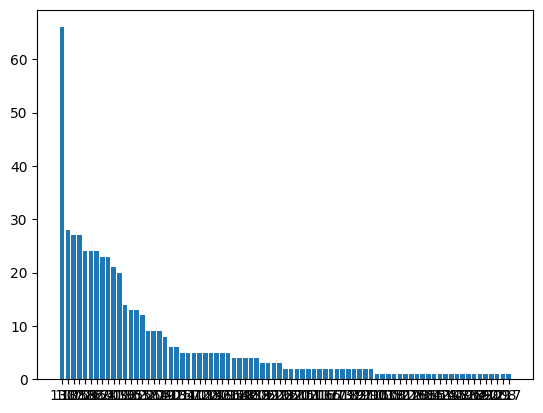

In [16]:
# train_df에 patient_id 컬럼 직접 추가
train_df = train_df.assign(
    patient_id=train_df['filename'].apply(lambda x: x.split('_')[0])
)

# 그 후에 value_counts 사용
patient_counts = train_df['patient_id'].value_counts().sort_values(ascending=False)

# DataFrame으로 변환
patient_counts_df = pd.DataFrame({
    'patient_id': patient_counts.index,
    'respiration_count': patient_counts.values
})

# 상위 5개 확인
plt.bar(patient_counts_df['patient_id'], patient_counts_df['respiration_count'])
patient_counts_df.head(10)

,patient_id,Cycle_count
0,130,507
1,107,231
2,158,217
3,154,208
4,203,185
5,172,176
6,138,149
7,193,138
8,213,129
9,186,126


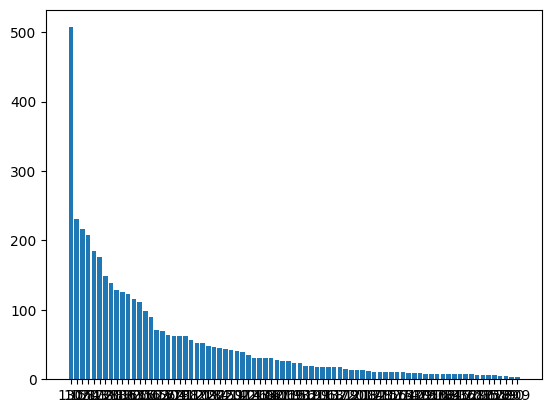

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# patient_id 추출 및 DataFrame 만들기
train_cycle = pd.DataFrame([(meta[0], meta[0].split('_')[0]) for _, _, meta in train_dataset], columns=['filename', 'patient_id'])

# patient_id별 발생 빈도수 계산
patient_counts_df = train_cycle['patient_id'].value_counts().reset_index()
patient_counts_df.columns = ['patient_id', 'Cycle_count']

# bar plot으로 시각화
plt.bar(patient_counts_df['patient_id'], patient_counts_df['Cycle_count'])
patient_counts_df.head(10)

#### Lung Sound Duration

mean duration: 2.7371561202317722 sec
Duration count per second:
0 sec: 194 cycles
1 sec: 805 cycles
2 sec: 1834 cycles
3 sec: 782 cycles
4 sec: 345 cycles
5 sec: 85 cycles
6 sec: 62 cycles
7 sec: 25 cycles
8 sec: 6 cycles
9 sec: 2 cycles
11 sec: 1 cycles
16 sec: 1 cycles


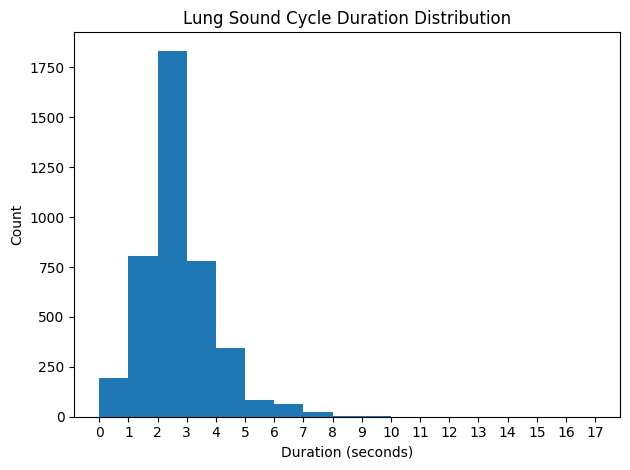

In [18]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# CycleDataset 인스턴스를 dataset이라고 가정
durations = [meta[1] for _, _, meta in train_dataset]

print(f"mean duration: {np.mean(durations)} sec")

# 히스토그램 그리기 (bin을 1초 단위로 설정)
plt.hist(durations, bins=np.arange(0, max(durations)+1, 1))

# 결과 출력
duration_counts = Counter(np.floor(durations).astype(int))  # 초 단위로 반올림 (소수점 버리기)
print("Duration count per second:")
for second in sorted(duration_counts.keys()):
    print(f"{second} sec: {duration_counts[second]} cycles")

# 그래프 설정
plt.title('Lung Sound Cycle Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.xticks(np.arange(0, max(durations)+1, 1))  # x축에 모든 초 표시
plt.tight_layout()
plt.show()


#### Mel Visualization

In [19]:
import random

random.seed(42)
indices = list(range(10))
samples_per_label = 3



In [20]:

sample_indices = random.sample(indices, samples_per_label)
print(sample_indices)



[1, 0, 4]


<Figure size 1200x600 with 0 Axes>

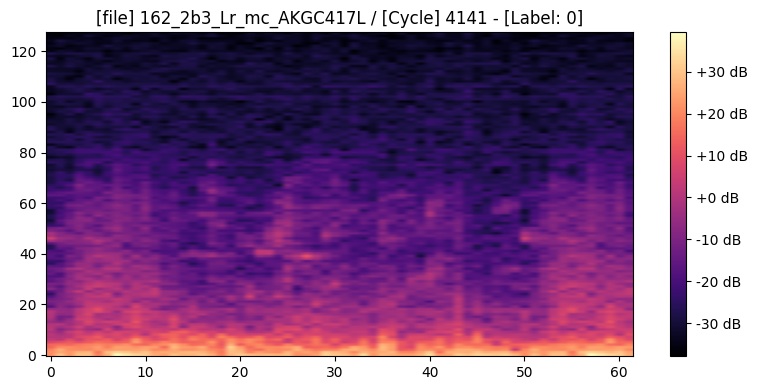

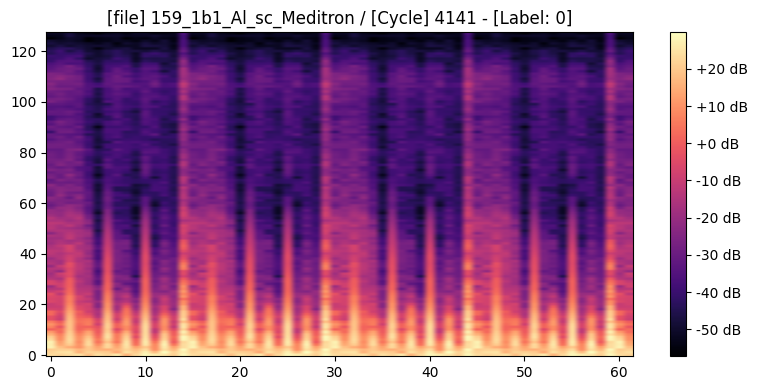

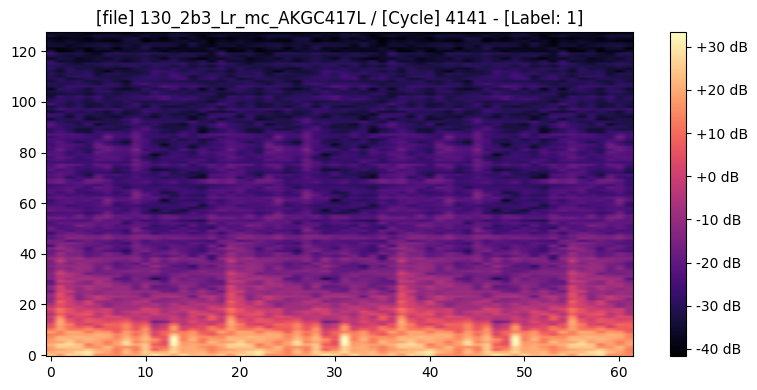

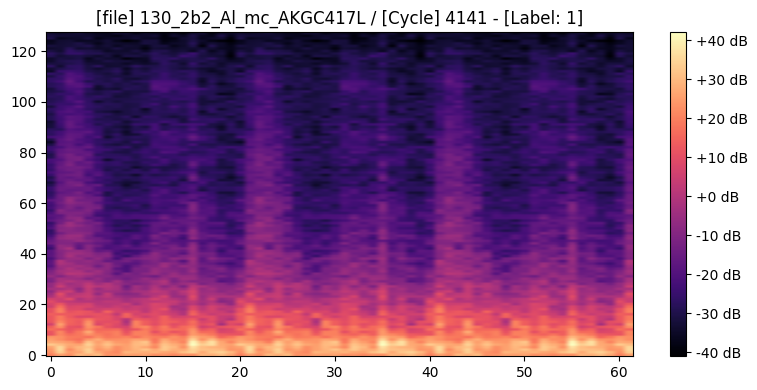

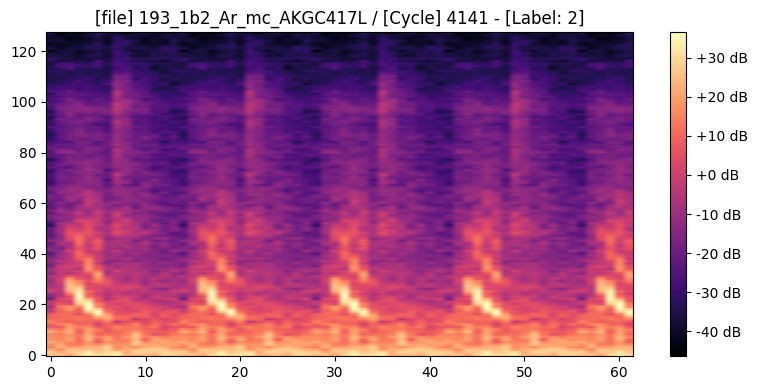

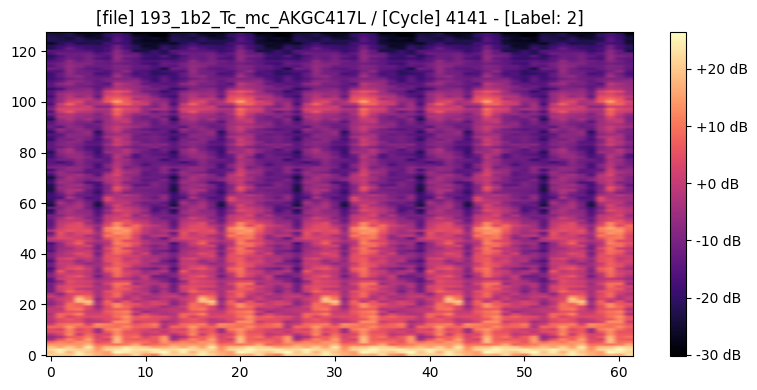

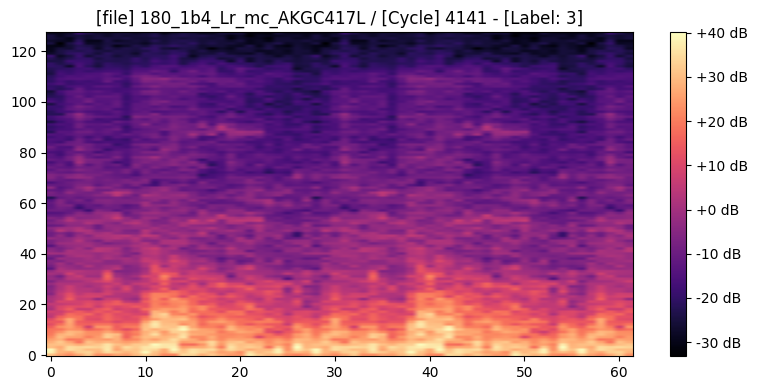

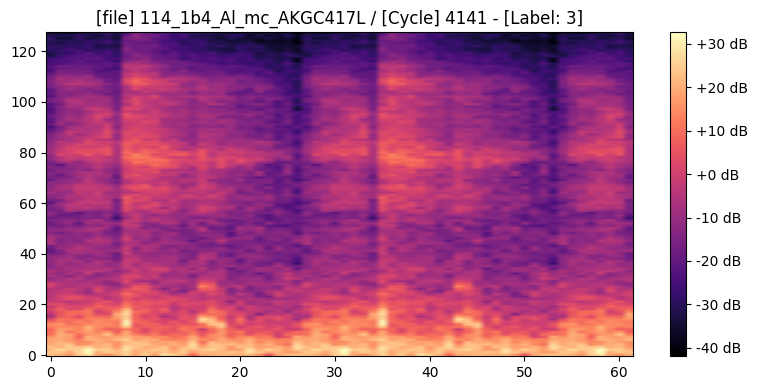

In [21]:
import random
import matplotlib.pyplot as plt

# label별로 인덱스를 그룹화
label_to_indices = {label: [] for label in set([train_dataset[idx][1] for idx in range(len(train_dataset))])}

for idx in range(len(train_dataset)):
    _, label, _ = train_dataset[idx]
    label_to_indices[label].append(idx)

# 각 label에서 2개씩 랜덤하게 샘플을 뽑아서 시각화
n_labels = len(label_to_indices)
samples_per_label = 2  # 각 label에서 2개씩 샘플 선택

plt.figure(figsize=(12, 6))

for i, (label, indices) in enumerate(label_to_indices.items()):
    # 각 label에서 2개씩 샘플을 랜덤하게 뽑기
    sample_indices = random.sample(indices, samples_per_label)

    for j, sample_idx in enumerate(sample_indices):
        mel, label, meta = train_dataset[sample_idx]

        # 시각화 (2개씩 가로로 나열)
        plt.figure(figsize=(8, 4))
        plt.imshow(mel.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
        plt.title(f"[file] {meta[0]} / [Cycle] {idx} - [Label: {label}]")
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()

plt.show()

### DataLoader - WeightedRandomSampler

- Pretext, Fine = 8:2 비율  
- StratifiedShuffle - 클래스 비율 유지
- WeightedRandomSampler 통한 DataLoader 구성

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset

# labels
labels = torch.tensor([label for _, label, _ in train_dataset])

# Stratified Split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for pretext_idx, finetune_idx in sss.split(torch.zeros(len(labels)), labels):
    print(f"Pretext set size: {len(pretext_idx)}, Finetune set size: {len(finetune_idx)}")

# Subset - DataLoader Input
pretext_dataset = Subset(train_dataset, pretext_idx)
finetune_dataset = Subset(train_dataset, finetune_idx)


Pretext set size: 3313, Finetune set size: 829


In [23]:
# Pretext DataLoader
pre_labels = torch.tensor([train_dataset[idx][1] for idx in pretext_idx])
pre_class_counts = torch.bincount(pre_labels)
pre_class_weights = 1.0 / pre_class_counts.float()
pre_sample_weights = pre_class_weights[pre_labels]

pre_sampler = WeightedRandomSampler(
    weights=pre_sample_weights,
    num_samples=len(pre_sample_weights),
    replacement=True
)

pretext_loader = DataLoader(
    pretext_dataset,
    batch_size=args.batch_size,
    sampler=pre_sampler,
    num_workers=0,
    drop_last=True,
    pin_memory=True
)

# finetune DataLoader
fin_labels = torch.tensor([train_dataset[idx][1] for idx in finetune_idx])
fin_class_counts = torch.bincount(fin_labels)
fin_class_weights = 1.0 / fin_class_counts.float()
fin_sample_weights = fin_class_weights[fin_labels]

fin_sampler = WeightedRandomSampler(
    weights=fin_sample_weights,
    num_samples=len(fin_sample_weights),
    replacement=True
)

finetune_loader = DataLoader(
    finetune_dataset,
    batch_size=args.batch_size,
    sampler=fin_sampler,
    num_workers=0,
    drop_last=True,
    pin_memory=True
)

# Test DataLoader


In [24]:
from collections import Counter

# pretext와 finetune 데이터셋의 라벨 분포 출력
pretext_labels = labels[pretext_idx]
finetune_labels = labels[finetune_idx]

print(f"[Pretext Dataset] Total: {len(pretext_labels)}")
print("Pretext label distribution:", Counter(pretext_labels.tolist()))
print(f"\n[Finetune Dataset] Total: {len(finetune_labels)}")
print("Finetune label distribution:", Counter(finetune_labels.tolist()))


[Pretext Dataset] Total: 3313
Pretext label distribution: Counter({0: 1650, 1: 972, 2: 401, 3: 290})

[Finetune Dataset] Total: 829
Finetune label distribution: Counter({0: 413, 1: 243, 2: 100, 3: 73})


## 2. Model

#### 2.1 Pre-trained ResNet50

In [43]:
import torch
import torchvision
from torch import Tensor
import torch.nn as nn
import math
import numpy as np
import torch.nn.functional as F
from torch.hub import load_state_dict_from_url


# # from https://github.com/raymin0223/patch-mix_contrastive_learning/blob/main/models/resnet.py

# class ResNet50(torchvision.models.resnet.ResNet):
#     def __init__(self, track_bn=True, num_classes):
#         def norm_layer(*args, **kwargs):
#             return nn.BatchNorm2d(*args, **kwargs, track_running_stats=track_bn)
#         super().__init__(torchvision.models.resnet.Bottleneck, [3, 4, 6, 3], norm_layer=norm_layer)
#         del self.fc
#         self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.final_feat_dim = 2048
#         self.num_classes = num_classes

#     def load_sl_official_weights(self, progress=True):
#         state_dict = load_state_dict_from_url(torchvision.models.resnet.model_urls['resnet50'],
#                                               progress=progress)

#         del state_dict['conv1.weight']
#         missing, unexpected = self.load_state_dict(state_dict, strict=False)
#         # if len(missing) > 0:
#             # raise AssertionError('Model code may be incorrect')

#     def _forward_impl(self, x: Tensor) -> Tensor:
#         # See note [TorchScript super()]
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.maxpool(x)

#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.layer4(x)

#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         # x = self.fc(x)

#         return x
import torch
import torch.nn as nn
import torchvision.models as models
from torch.hub import load_state_dict_from_url

# class ResNet50(models.resnet.ResNet):
#     def __init__(self, track_bn=True, pretrained=False, simclr=False):
#         def norm_layer(*args, **kwargs):
#             return nn.BatchNorm2d(*args, **kwargs, track_running_stats=track_bn)
#         super().__init__(models.resnet.Bottleneck, [3, 4, 6, 3], norm_layer=norm_layer)
#         del self.fc
#         self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.final_feat_dim = 2048

#         if pretrained:
#             self.load_sl_official_weights()
#         if simclr:
#             self.load_ssl_official_weights()

#     def load_sl_official_weights(self, progress=True):
#         # 수정된 부분: model_urls 경로 변경
#         state_dict = load_state_dict_from_url(models.resnet50.model_urls['resnet50'],
#                                               progress=progress)
#         del state_dict['conv1.weight']
#         self.load_state_dict(state_dict, strict=False)

#     def load_ssl_official_weights(self, progress=True):
#         from pl_bolts.models.self_supervised import SimCLR
        
#         weight_path = 'https://pl-bolts-weights.s3.us-east-2.amazonaws.com/simclr/bolts_simclr_imagenet/simclr_imagenet.ckpt'
#         simclr = SimCLR.load_from_checkpoint(weight_path, strict=False)

#         state_dict = {}
#         for k, v in simclr.state_dict().items():
#             if 'encoder.' in k:
#                 k = k.replace('encoder.', '')
#             if 'fc' not in k or 'project' not in k:
#                 state_dict[k] = v
#         self.load_state_dict(state_dict, strict=False)

#     def _forward_impl(self, x: torch.Tensor) -> torch.Tensor:
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.maxpool(x)

#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.layer4(x)

#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)

#         return x

def backbone_resnet(dim=args.mlp_dim, mlp=False):
    from torchvision.models import resnet50

    resnet = resnet50(weights=None, num_classes=dim)  # deprecated 대응

    # 1채널 입력 변경
    resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Pretrained weight 불러오기 (conv1, fc 제외)
    state_dict = load_state_dict_from_url(
        'https://download.pytorch.org/models/resnet50-19c8e357.pth',
        progress=True
    )
    for k in ['conv1.weight', 'fc.weight', 'fc.bias']:
        if k in state_dict:
            del state_dict[k]

    resnet.load_state_dict(state_dict, strict=False)

    return resnet

In [44]:
# # summary 함수 사용: (채널, 높이, 너비) 크기를 지정
summary(backbone_resnet().to(device), input_size=(1, 224, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 64, 112, 32]           3,136
       BatchNorm2d-2          [-1, 64, 112, 32]             128
              ReLU-3          [-1, 64, 112, 32]               0
         MaxPool2d-4           [-1, 64, 56, 16]               0
            Conv2d-5           [-1, 64, 56, 16]           4,096
       BatchNorm2d-6           [-1, 64, 56, 16]             128
              ReLU-7           [-1, 64, 56, 16]               0
            Conv2d-8           [-1, 64, 56, 16]          36,864
       BatchNorm2d-9           [-1, 64, 56, 16]             128
             ReLU-10           [-1, 64, 56, 16]               0
           Conv2d-11          [-1, 256, 56, 16]          16,384
      BatchNorm2d-12          [-1, 256, 56, 16]             512
           Conv2d-13          [-1, 256, 56, 16]          16,384
      BatchNorm2d-14          [-1, 256,

#### 2.2 Moco

In [45]:
import torch
import torch.nn as nn

class MoCo(nn.Module):
    """
    Build a MoCo model with: a query encoder, a key encoder, and a queue
    https://arxiv.org/abs/1911.05722
    """

    def __init__(self, base_encoder, dim=args.mlp_dim, K=args.K, m=args.m, T=args.T, mlp=args.mlp):
        """
        dim: feature dimension (default: 128)
        K: queue size; number of negative keys (default: 8192) # original=65536
        m: moco momentum of updating key encoder (default: 0.999)
        T: softmax temperature (default: 0.07)
        mlp: if True, use MLP head (default: True)
        """
        super(MoCo, self).__init__()
 
        self.K = K
        self.m = m
        self.T = T

        # create the encoders
        # num_classes is the output fc dimension
        self.encoder_q = base_encoder(dim=args.mlp_dim, mlp=args.mlp)
        self.encoder_k = base_encoder(dim=args.mlp_dim, mlp=args.mlp)

        if mlp:  # hack: brute-force replacement
            dim_mlp = self.encoder_q.fc.weight.shape[1]
            self.encoder_q.fc = nn.Sequential(
                nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.encoder_q.fc
            )
            self.encoder_k.fc = nn.Sequential(
                nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.encoder_k.fc
            )

        for param_q, param_k in zip(
            self.encoder_q.parameters(), self.encoder_k.parameters()
        ):
            param_k.data.copy_(param_q.data)  # initialize
            param_k.requires_grad = False  # not update by gradient

        # create the queue
        self.register_buffer("queue", torch.randn(dim, K))
        self.queue = nn.functional.normalize(self.queue, dim=0)

        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        """
        Momentum update of the key encoder
        """
        for param_q, param_k in zip(
            self.encoder_q.parameters(), self.encoder_k.parameters()
        ):
            param_k.data = param_k.data * self.m + param_q.data * (1.0 - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        # gather keys before updating queue
        keys = keys

        batch_size = keys.shape[0]

        ptr = int(self.queue_ptr)
        assert self.K % batch_size == 0  # for simplicity

        # replace the keys at ptr (dequeue and enqueue)
        self.queue[:, ptr : ptr + batch_size] = keys.T
        ptr = (ptr + batch_size) % self.K  # move pointer

        self.queue_ptr[0] = ptr

    def forward(self, im_q, im_k):
        """
        Input:
            im_q: a batch of query images
            im_k: a batch of key images
        Output:
            logits, targets
        """

        # compute query features
        q = self.encoder_q(im_q)  # queries: NxC
        q = nn.functional.normalize(q, dim=1)

        # compute key features
        with torch.no_grad():  # no gradient to keys
            self._momentum_update_key_encoder()  # update the key encoder
            k = self.encoder_k(im_k)  # keys: NxC
            k = nn.functional.normalize(k, dim=1)

        # compute logits
        # Einstein sum is more intuitive
        # positive logits: Nx1
        l_pos = torch.einsum("nc,nc->n", [q, k]).unsqueeze(-1) # [N, 1]
        # negative logits: NxK
        l_neg = torch.einsum("nc,ck->nk", [q, self.queue.clone().detach()])  # [N,dim] * [dim,K] = [N,K]


        # logits: Nx(1+K)
        logits = torch.cat([l_pos, l_neg], dim=1) # [N, 1+K]

        # apply temperature
        logits /= self.T

        # labels: positive key indicators
        labels = torch.zeros(logits.shape[0], dtype=torch.long).cuda()

        # dequeue and enqueue
        self._dequeue_and_enqueue(k)

        return logits, labels

## 3. Training

In [46]:
next(iter(pretext_loader))[0][0].shape

torch.Size([1, 128, 62])

#### 3.2 TestData Loader

In [29]:
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=0)


#### 3.3 Aug

In [30]:
def aug(repeat_mel):
    aug1, aug2, aug3 = apply_spec_augment(repeat_mel)
    return aug1, aug2, aug3

#### Wandb

In [31]:
import wandb

wandb.login(key='37e029d940c3722b338d8079392931beecdbef3b')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/sbw/.netrc
wandb: Currently logged in as: boaz_woony (boaz_woony-boaz) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [48]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [49]:
project_name = 'sbw_3.2_New_Moco__lr0.03_time0.7_freq0.7_256batch_0.99momentum'

In [50]:
args.weight_decay

0.0001

In [51]:

import wandb

# wandb 초기화 (프로젝트명, 실험 이름 등 설정)
wandb.init(
    project="SBW_ICBHI_SSL",           # 프로젝트 이름
    name=f"{project_name}", # 실험 이름
    config=args.__dict__  # 클래스 내부 모든 속성 전달
)


## Visualization


Original dB Spectrogram shape: torch.Size([1, 128, 62])


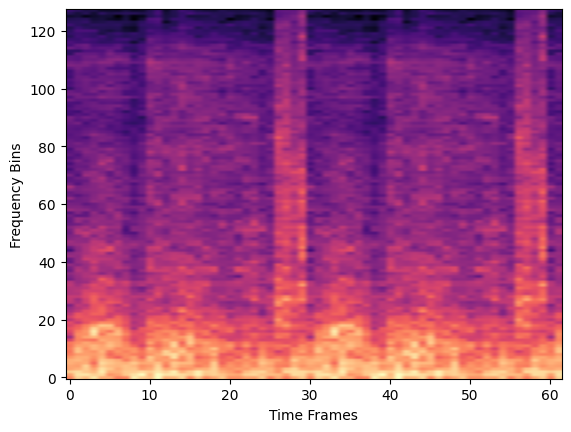

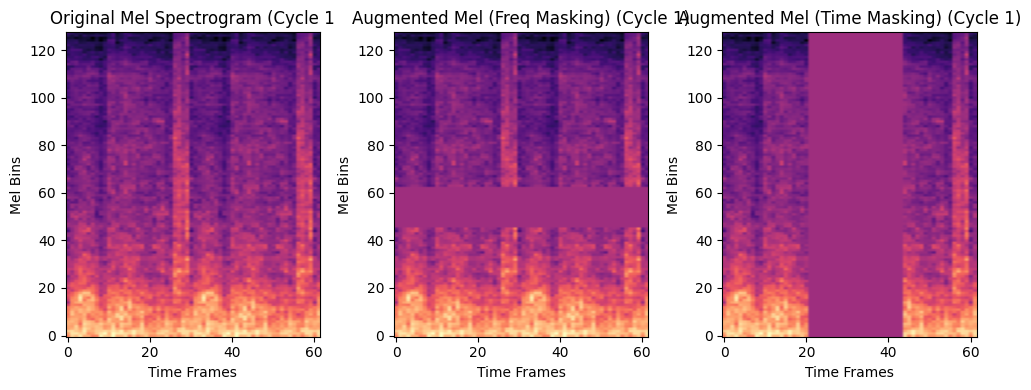

Original dB Spectrogram shape: torch.Size([1, 128, 62])


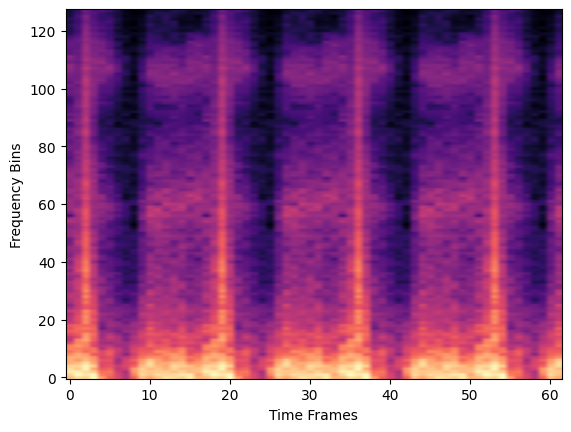

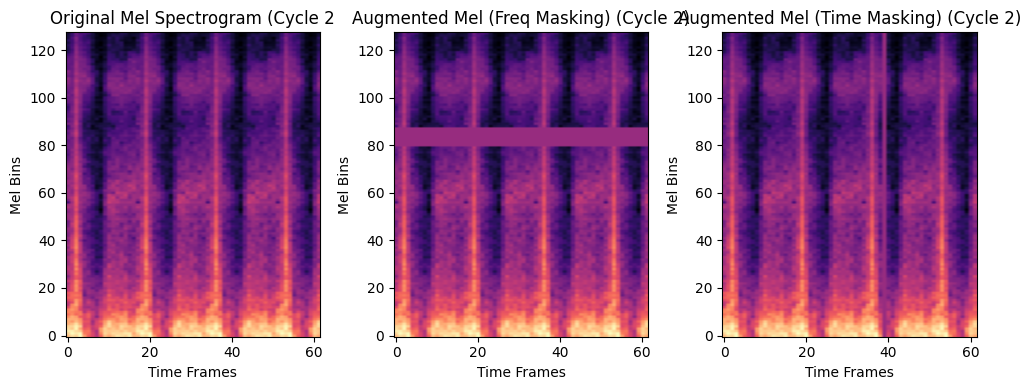

Original dB Spectrogram shape: torch.Size([1, 128, 62])


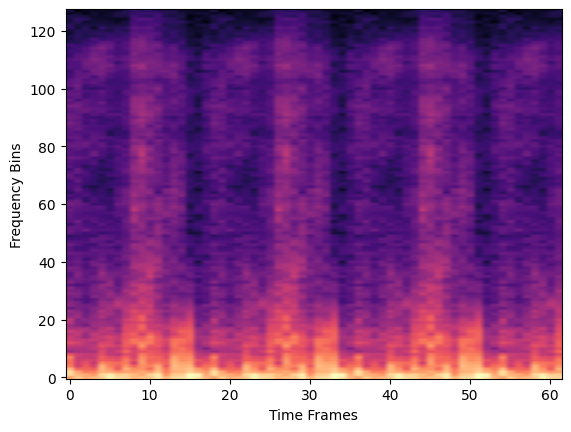

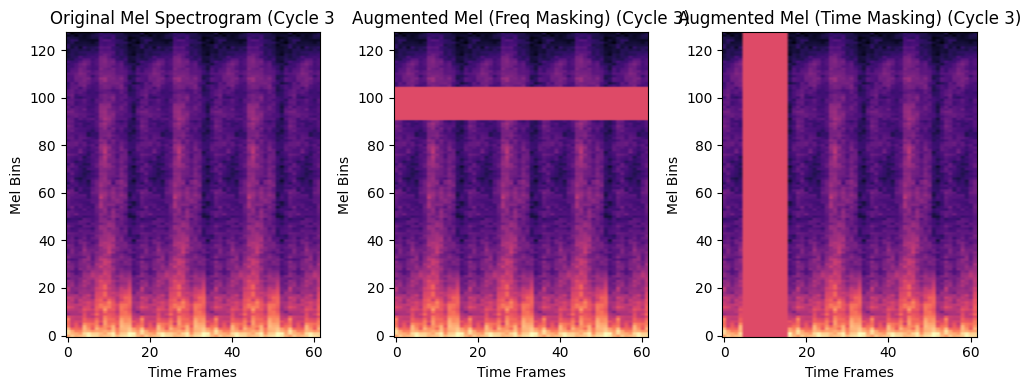

In [52]:
import matplotlib.pyplot as plt
import torchaudio.transforms as T
from itertools import islice

n_list = 3

# 🔹 각 파일별로 cycle segments 시각화
for i, cycle_data in enumerate(islice(pretext_dataset, n_list)):
    target_frame = 62
    cycle, label, _ = cycle_data

    # 1. segment repeat = 🔹 전체 원본 db 스펙트로그램 (크게 출력)
    origin_db = cycle  # 첫 번째 세그먼트에서 전체 db 스펙트로그램 사용
    print(f"Original dB Spectrogram shape: {origin_db.shape}")  # 🔹 데이터 shape 확인


    # 🔹 원본 dB Spectrogram을 크게 시각화
    fig, main_ax = plt.subplots()
    main_ax.imshow(origin_db.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    # main_ax.set_title(f"Original dB Spectrogram - {filename}")
    main_ax.set_xlabel("Time Frames")
    main_ax.set_ylabel("Frequency Bins")
    plt.show()

    # 2.세그먼트 개수에 맞게 서브플롯 생성 (repeat + 두 가지 Augment 버전)
    fig, axes = plt.subplots(1, 3, figsize=(10, 4)) # plt.subplots(행, 열, figsize)

    ax1, ax2, ax3 = axes

    repeat = repeat_or_truncate_segment(cycle, target_frame)
    augmented_spec1, augmented_spec2, augmented_spec3 = apply_spec_augment(repeat)

    # 🔹 원본 repeaet Mel Spectrogram 시각화
    ax1.imshow(repeat.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax1.set_title(f"Original Mel Spectrogram (Cycle {i+1}")
    ax1.set_xlabel("Time Frames")
    ax1.set_ylabel("Mel Bins")

    # 🔹 주파수 마스킹이 적용된 Mel Spectrogram 시각화
    ax2.imshow(augmented_spec1.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax2.set_title(f"Augmented Mel (Freq Masking) (Cycle {i+1})")
    ax2.set_xlabel("Time Frames")
    ax2.set_ylabel("Mel Bins")

    # 🔹 시간 마스킹이 적용된 Mel Spectrogram 시각화
    ax3.imshow(augmented_spec2.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax3.set_title(f"Augmented Mel (Time Masking) (Cycle {i+1})")
    ax3.set_xlabel("Time Frames")
    ax3.set_ylabel("Mel Bins")

    plt.tight_layout()
    plt.show()


#### 3.4 Train

In [53]:
import math
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# 1. MoCo 모델 생성
# default - base_encoder, dim=128, K=8192, m=0.999, T=0.07
model = MoCo(base_encoder = backbone_resnet, mlp=True).cuda()

# 2. loss function (criterion)
criterion = nn.CrossEntropyLoss() # .cuda(device.gpu)

# 3.Optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    args.lr,
    momentum=args.momentum,
    weight_decay=args.weight_decay,
)

# 4. Scheduler 정의
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=args.epochs - args.warm_epochs,  # Warm-up 이후 cosine decay
    eta_min=0  # 최종적으로 0까지 떨어질 수 있도록
)

# Best loss 초기화
best_loss = float('inf')
best_epoch = -1


for epoch in range(args.epochs):
    
    # Warm-up 또는 Cosine 적용
    if args.warm and epoch < args.warm_epochs:
        lr = args.warmup_from + (args.warmup_to - args.warmup_from) * epoch / args.warm_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        print(f"[Warm-up] Epoch {epoch}, LR: {lr:.6f}")
    else:
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        print(f"[Cosine] Epoch {epoch}, LR: {lr:.6f}")

    # ===============================
    # 2. Training
    # ===============================
    
    model.train()
    total_train_loss = 0.0

    for i, (repeat_mel, label, _) in enumerate(pretext_loader): # label 여기선 사용 X
        im_q, im_k, _ = aug(repeat_mel)
        im_q = im_q.cuda(device=args.gpu, non_blocking=True)
        im_k = im_k.cuda(device=args.gpu, non_blocking=True)

        optimizer.zero_grad()
        output, target = model(im_q=im_q, im_k=im_k)
        loss = criterion(output, target) # NCE Loss ( = N*[1+k]의 유사도가 모두 0이 되도록 loss 조정)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        # if i % args.print_freq == 0:
        #     print(f"[Epoch {epoch} | Step {i}] Train Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(pretext_loader)
    print(f"Epoch {epoch} | Avg Train Loss: {avg_train_loss:.4f}")

    # =====================================
    # 3. Logging with wandb
    # =====================================
    wandb.log({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        # "lr": lr
    })

    # =====================================
    # 4. Checkpoint (Every 100 epochs)
    # =====================================
    if (epoch + 1) % 100 == 0:
        ckpt_path = './pth/' + f"{project_name}_{epoch:03d}.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
        }, ckpt_path)
        print(f"💾 Saved checkpoint to {ckpt_path}")

    # ===============================
    # 5. Save Best Checkpoint
    # ===============================
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        best_epoch = epoch
        best_ckpt_path = './best/'+ f"{project_name}_best_checkpoint.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': best_loss
        }, best_ckpt_path)
        print(f"=> Saved best checkpoint (epoch: {epoch}, loss: {best_loss:.4f})")

wandb.finish()

[Warm-up] Epoch 0, LR: 0.003000
Epoch 0 | Avg Train Loss: 6.6162
=> Saved best checkpoint (epoch: 0, loss: 6.6162)
[Warm-up] Epoch 1, LR: 0.005700
Epoch 1 | Avg Train Loss: 8.1529
[Warm-up] Epoch 2, LR: 0.008400
Epoch 2 | Avg Train Loss: 8.2144
[Warm-up] Epoch 3, LR: 0.011100
Epoch 3 | Avg Train Loss: 7.9919
[Warm-up] Epoch 4, LR: 0.013800
Epoch 4 | Avg Train Loss: 7.9146
[Warm-up] Epoch 5, LR: 0.016500
Epoch 5 | Avg Train Loss: 7.9482
[Warm-up] Epoch 6, LR: 0.019200
Epoch 6 | Avg Train Loss: 7.9475
[Warm-up] Epoch 7, LR: 0.021900
Epoch 7 | Avg Train Loss: 7.8577
[Warm-up] Epoch 8, LR: 0.024600
Epoch 8 | Avg Train Loss: 7.7219
[Warm-up] Epoch 9, LR: 0.027300
Epoch 9 | Avg Train Loss: 7.4993
[Cosine] Epoch 10, LR: 0.027299
Epoch 10 | Avg Train Loss: 7.3165
[Cosine] Epoch 11, LR: 0.027297
Epoch 11 | Avg Train Loss: 7.0989
[Cosine] Epoch 12, LR: 0.027293
Epoch 12 | Avg Train Loss: 6.9942
[Cosine] Epoch 13, LR: 0.027287
Epoch 13 | Avg Train Loss: 6.9208
[Cosine] Epoch 14, LR: 0.027280
Epoc

KeyboardInterrupt: 

In [ ]:
'./best/'+ f"{project_name}_best_checkpoint.pth.tar"

In [ ]:
wandb.finish()

## Fine tuning

In [ ]:
len(test_dataset)

In [57]:
class Args:
    gpu = 0
    batch_size = 128
    workers = 4
    epochs = 150
    lr = 0.02 # origin : 30
    momentum = 0.9
    weight_decay = 0
    out_dim = 128

args = Args()

In [58]:
finetune_project_name= 'sbw_3.0_Moco_Finetune_ICBHI_Standard_2_128batch_lr0.02'

In [ ]:
import wandb

# wandb 초기화 (프로젝트명, 실험 이름 등 설정)
wandb.init(
    project="SBW_ICBHI_SSL",           # 프로젝트 이름
    name=f"{finetune_project_name}", # 실험 이름
    config={
        "epochs": 150,
        "batch_size": 128,
        "lr": 0.02,
        "momentum": 0.9,
        "weight_decay": 0
    }
)


In [ ]:
import os
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score


# 1. Model Load
# ckpt_path
load_ckpt_path = '/content/drive/MyDrive/BOAZ_ICBHI/pth/best/'
save_ckpt_path = '/content/drive/MyDrive/BOAZ_ICBHI/fine_tune_pth/'

# Load Encoder
model_eval = MoCo(base_encoder=backbone_resnet, dim=128, mlp=False)
checkpoint = torch.load(f"{load_ckpt_path}/sbw_3.0_Moco_ICBHI_Standard_2_best_checkpoint.pth.tar",
                      map_location=device)  # map_location 파라미터 추가
model_eval.load_state_dict(checkpoint["state_dict"])
encoder = model_eval.encoder_q.eval().to(device)

# 2. Dataset 정의
# Dataset 정의는 이미 되어있음 - test_loader

# 3. Fine-tuning을 위한 분류 모델 정의 ( Data 개수 작으므로, encoder 파라미터 frozen )
class FineTuningModel(nn.Module):
    def __init__(self, encoder, out_dim=args.out_dim, num_classes=4):
        super().__init__()
        self.encoder = encoder
        # 마지막 FC layer를 제외한 encoder의 모든 레이어 freeze
        for param in self.encoder.parameters():
            param.requires_grad = False

        # 새로운 분류 헤드 추가
        self.classifier = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)


# 4. 모델, 손실 함수, 옵티마이저 설정
model = FineTuningModel(encoder, out_dim = args.out_dim).to(device)
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
optimizer = optim.SGD(model.classifier.parameters(), lr = args.lr, momentum=0.9,weight_decay=0)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Best loss 초기화
best_loss = float('inf')
best_epoch = -1

# 5. Validation loop
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels, _ in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    accuracy = 100. * correct / total
    avg_loss = running_loss / len(val_loader)

    return avg_loss, accuracy, all_labels, all_preds


# 6. Fine-tuning 실행

for epoch in range(args.epochs):
    # # ===============================
    # # 1. Learning Rate Scheduler
    # # ===============================
    # lr = args.lr
    # if args.cos:
    #     lr *= 0.5 * (1. + math.cos(math.pi * epoch / args.epochs))
    # else:
    #     for milestone in args.schedule:
    #         if epoch >= milestone:
    #             lr *= 0.1
    # for param_group in optimizer.param_groups:
    #     param_group['lr'] = lr

    # print(f"\n==> [Epoch {epoch}] Adjusted learning rate: {lr:.6f}")

    # ===============================
    # 2. Training
    # ===============================
    model.train()
    total_loss = 0.0
    total_predictions = 0.0
    correct_predictions = 0.0

    pbar = tqdm(finetune_loader, desc='Training')
    for i, (cycle, labels, _) in enumerate(pbar):
        # Forward pass
        cycle = cycle.cuda(args.gpu)
        labels = labels.cuda(args.gpu)

        # backpropagation
        optimizer.zero_grad()
        output = model(cycle)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        # loss 계산
        total_loss += loss.item()

        _, predicted = torch.max(output.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': total_loss/total_predictions, 'train acc': 100.*correct_predictions/total_predictions})

    train_loss = total_loss / len(finetune_loader)
    train_acc = 100.*correct_predictions/total_predictions

    print(f"==> Epoch {epoch} completed.")
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')

    # ===============================
    # 3. Validation
    # ===============================

    test_loss, test_acc, all_labels, all_predictions = validate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    # 성능 지표
    precision = precision_score(all_labels.numpy(), all_predictions.numpy(), average='macro')
    recall = recall_score(all_labels.numpy(), all_predictions.numpy(), average='macro')
    f1 = f1_score(all_labels.numpy(), all_predictions.numpy(), average='macro')

    # 특이도

    from sklearn.metrics import confusion_matrix

    def compute_specificity(y_true, y_pred, num_classes):
        cm = confusion_matrix(y_true, y_pred)
        specificities = []

        for i in range(num_classes):
            TP = cm[i, i]
            FN = cm[i, :].sum() - TP
            FP = cm[:, i].sum() - TP
            TN = cm.sum() - (TP + FN + FP)

            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
            specificities.append(specificity)

        return specificities

    specificity_per_class = compute_specificity(all_labels.numpy(), all_predictions.numpy(), num_classes=4)
    specificity = sum(specificity_per_class) / len(specificity_per_class)


    # =====================================
    # 4. Logging with wandb
    # =====================================

    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    def log_confusion_matrix_wandb(y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title('Confusion Matrix')
        plt.tight_layout()

        # wandb에 이미지로 로그
        wandb.log({"confusion_matrix": wandb.Image(fig)})
        plt.close(fig)



    wandb.log({
        "Finetune/epoch": epoch,
        "Finetune/train_loss": train_loss,
        "Finetune/train_accuracy": train_acc,
        "Finetune/test_loss": test_loss,
        "Finetune/test_accuracy": test_acc,
        "Metrics/precision": precision,
        "Metrics/recall": recall,
        "Metrics/f1_score": f1,
        "Metrics/specificity": specificity
    })

    # 혼동행렬은 따로 이미지로 로그
    log_confusion_matrix_wandb(
        y_true=all_labels.numpy(),
        y_pred=all_predictions.numpy(),
        class_names=["Normal", "Creekle", "Wheezle", "Both"]
    )

    # =====================================
    # 4. Checkpoint (Every 100 epochs)
    # =====================================
    if (epoch + 1) % 100 == 0:
        ckpt_path = save_ckpt_path + f"{finetune_project_name}_{epoch:03d}.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
        }, ckpt_path)
        print(f"💾 Saved checkpoint to {save_ckpt_path}")

    # ===============================
    # 5. Save Best Checkpoint
    # ===============================
    if train_loss < best_loss:
        best_loss = train_loss
        best_epoch = epoch
        best_ckpt_path = save_ckpt_path +"best/"+ f"{finetune_project_name}_best.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': best_loss
        }, best_ckpt_path)
        print(f"=> Saved best checkpoint (epoch: {epoch}, loss: {best_loss:.4f})")

wandb.finish()